In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = ['/home/junjieyu/Github/UrbSprIrr/data/workdir/outputfolder/lnd/hist/urbirr_ug_compare.clm2.h0.2006-01-01-00000.nc']

In [3]:
ds = xr.open_dataset(data[0]).sel(time=slice('2016', '2020')).sel(landunit=1)
print(ds['TBUILD'].max())
ds

<xarray.DataArray 'TBUILD' ()> Size: 4B
array(301.15, dtype=float32)


<xarray.Dataset> Size: 61MB
Dimensions:             (levgrnd: 25, levlak: 10, levdcmp: 1, time: 87696,
                         hist_interval: 2, lndgrid: 1, column: 6, gridcell: 1,
                         pft: 6, levsoi: 20)
Coordinates:
  * levgrnd             (levgrnd) float32 100B 0.01 0.04 0.09 ... 28.87 42.0
  * levlak              (levlak) float32 40B 0.05 0.6 2.1 ... 25.6 34.33 44.78
  * levdcmp             (levdcmp) float32 4B 1.0
  * time                (time) datetime64[ns] 702kB 2016-01-01 ... 2020-12-31...
Dimensions without coordinates: hist_interval, lndgrid, column, gridcell, pft,
                                levsoi
Data variables: (12/129)
    mcdate              (time) int32 351kB ...
    mcsec               (time) int32 351kB ...
    mdcur               (time) int32 351kB ...
    mscur               (time) int32 351kB ...
    nstep               (time) int32 351kB ...
    time_bounds         (time, hist_interval) datetime64[ns] 1MB ...
    ...                  ...
    URBAN_AC            (time) float32 351kB ...
    URBAN_HEAT          (time) float32 351kB ...
    WASTEHEAT           (time) float32 351kB ...
    WBT                 (time) float32 351kB ...
    Wind                (time) float32 351kB ...
    ZWT                 (time) float32 351kB ...
Attributes: (12/38)
    title:                                     CLM History file information
    comment:                                   NOTE: None of the variables ar...
    Conventions:                               CF-1.0
    history:                                   created on 12/14/25 15:07:42
    source:                                    Community Land Model CLM4.0
    hostname:                                  clmu-app
    ...                                        ...
    ctype_urban_shadewall:                     73
    ctype_urban_impervious_road:               74
    ctype_urban_pervious_road:                 75
    cft_c3_crop:                               1
    cft_c3_irrigated:                          2
    time_period_freq:                          minute_30

In [4]:
obs = xr.open_dataset('JP-Yoyogi_clean_observations_v1.nc').sel(time=slice('2016', '2020'))
obs

<xarray.Dataset> Size: 3MB
Dimensions:    (time: 35064)
Coordinates:
  * time       (time) datetime64[ns] 281kB 2016-03-31T15:00:00 ... 2020-03-31...
Data variables: (12/26)
    SWdown     (time) float32 140kB ...
    LWdown     (time) float32 140kB ...
    Tair       (time) float32 140kB ...
    Qair       (time) float32 140kB ...
    PSurf      (time) float32 140kB ...
    Rainf      (time) float32 140kB ...
    ...         ...
    Wind_N_qc  (time) int8 35kB ...
    Wind_E_qc  (time) int8 35kB ...
    SWup_qc    (time) int8 35kB ...
    LWup_qc    (time) int8 35kB ...
    Qle_qc     (time) int8 35kB ...
    Qh_qc      (time) int8 35kB ...
Attributes: (12/24)
    title:                      Flux tower observations from JP-Yoyogi (after...
    summary:                    Quality controlled flux tower observations fo...
    sitename:                   JP-Yoyogi
    long_sitename:              Yoyogi, Tokyo, Japan
    version:                    v1
    keywords:                   urban, flux tower, eddy covariance, observations
    ...                         ...
    observations_contact:       Hirofumi Sugawara (hiros@nda.ac.jp)
    observations_reference:     Hirano, Sugawara, Murayama, Kondo (2015): htt...
    date_created:               2022-09-22 15:41:19
    source:                     https://github.com/matlipson/urban-plumber_pi...
    comment:                    Observations for turbulent fluxes removed fro...
    history:                    v0.9 (2021-09-08): beta issue; v1 (2022-09-15...

In [5]:
ds['time'] = ds['time'].dt.round('min') + np.timedelta64(9, 'h')
obs['time'] = obs['time'].dt.round('min') + np.timedelta64(9, 'h')
ds['time'] = ds['time'] - np.timedelta64(1800, 's')
df = ds[['Qle','Qh','SWup','LWup']].to_dataframe()
df_ds = obs[['Qle','Qh','SWup','LWup']].to_dataframe()
df = df.merge(df_ds, on='time', suffixes=('_usp', '_obs'))
df.head(1)

,Qle_usp,Qh_usp,SWup_usp,LWup_usp,Qle_obs,Qh_obs,SWup_obs,LWup_obs
time,,,,,,,,
2016-04-01,1.185521,8.992134,0.0,385.766602,NaN,NaN,NaN,386.209015


In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import warnings
from datetime import datetime
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

def plotting(df, save_path):
    var_list = ['SWup','LWup','Qle','Qh']
    unit = ['W/m$\mathrm{^{2}}$', 'W/m$\mathrm{^{2}}$', 'W/m$\mathrm{^{2}}$', 'W/m$\mathrm{^{2}}$']
    lim = [[-10, 130], [280, 600], [-120, 350], [-150, 500], [-0.1, 1.3]]


    for var in var_list:
        fig = plt.figure(figsize=(12, 5))

        df_plot = df[[f'{var}_usp', f'{var}_obs']].dropna()
        df_mean = df_plot[[f'{var}_usp', f'{var}_obs']].groupby(df_plot.index.hour).mean()
        df_std = df_plot[[f'{var}_usp', f'{var}_obs']].groupby(df_plot.index.hour).std()

        mae = mean_absolute_error(df_plot[f'{var}_obs'],df_plot[f'{var}_usp'])
                            #mean_absolute_percentage_error(df_plot[f'{var}_usp'], df_plot[f'{var}_obs'])#mean_squared_error(df_plot[f'{var}_usp'], df_plot[f'{var}_obs'])
        R, _ = pearsonr(df_plot[f'{var}_usp'], df_plot[f'{var}_obs'])

        ax = fig.add_subplot(1, 2, 1)

        if var == 'SWup':
            for h in range(0,24):
                if h not in df_mean.index:
                    df_mean.loc[h] = [0,0]
                    df_std.loc[h] = [0,0]
        df_mean = df_mean.sort_index()
        df_std = df_std.sort_index()

        ax.plot(df_mean.index, df_mean[f'{var}_usp'], color="#E02927", label='Simulated')
        ax.fill_between(df_mean.index, df_mean[f'{var}_usp']-df_std[f'{var}_usp'], df_mean[f'{var}_usp']+df_std[f'{var}_usp'], color="#E02927", alpha=0.2)
        ax.plot(df_mean.index, df_mean[f'{var}_obs'], color="#3964DF", label='Observed')
        ax.fill_between(df_mean.index, df_mean[f'{var}_obs']-df_std[f'{var}_obs'], df_mean[f'{var}_obs']+df_std[f'{var}_obs'], color="#3964DF", alpha=0.2)
        ax.set_ylabel(f'{var} [{unit[var_list.index(var)]}]', fontsize=14)
        ax.set_xlabel('Local hour of day', fontsize=14)
        
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.legend(frameon=False, fontsize=14)

        ax = fig.add_subplot(1, 2, 2)
        h = sns.histplot(
            x=f'{var}_usp',
            y=f'{var}_obs',
            data=df_plot,
            ax=ax,
            cmap='rainbow',
            bins=120,
            #cbar=True,
            #cbar_kws={'label': 'Counts'},
        )
        cbar = h.figure.colorbar(h.collections[0], ax=ax)
        cbar.set_label('Counts', fontsize=14)
        cbar.ax.tick_params(labelsize=12)
        ax.plot(lim[var_list.index(var)], lim[var_list.index(var)], color='black', linestyle='--')
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.set_xlabel(f'Simulated {var} [{unit[var_list.index(var)]}]', fontsize=14)
        ax.set_ylabel(f'Observed {var} [{unit[var_list.index(var)]}]',  fontsize=14)
        ax.set_xlim(lim[var_list.index(var)])
        ax.set_ylim(lim[var_list.index(var)])
        ax.set_title(f'MAE: {mae:.2f}, R: {R:.2f}', fontsize=14, loc='left')
        print(f'{var} MAE: {mae:.2f}')

        fig.tight_layout()
        fig.savefig(save_path + f'_{var}.pdf', dpi=300, bbox_inches='tight')
        plt.show()

SWup MAE: 5.16


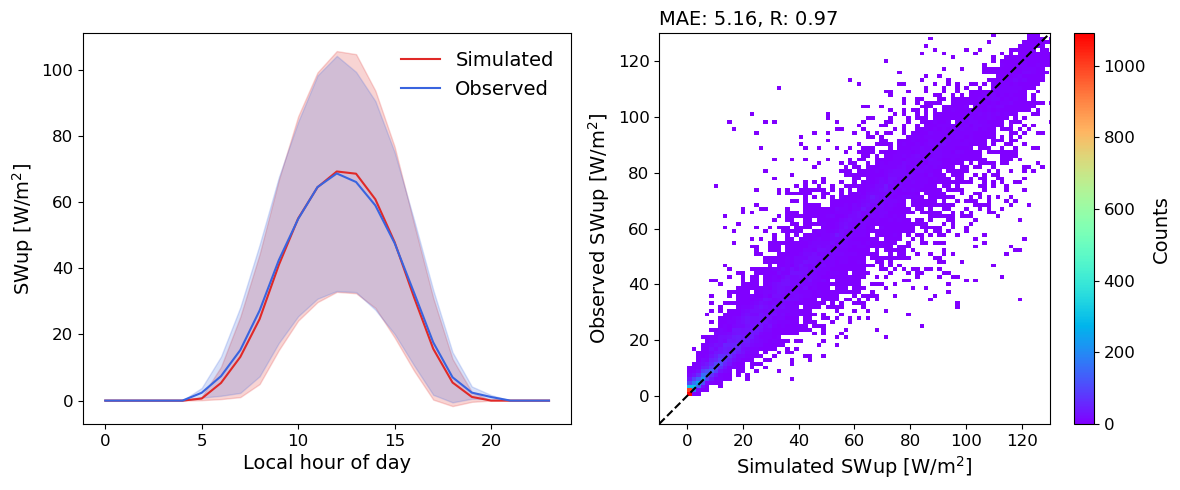

LWup MAE: 12.43


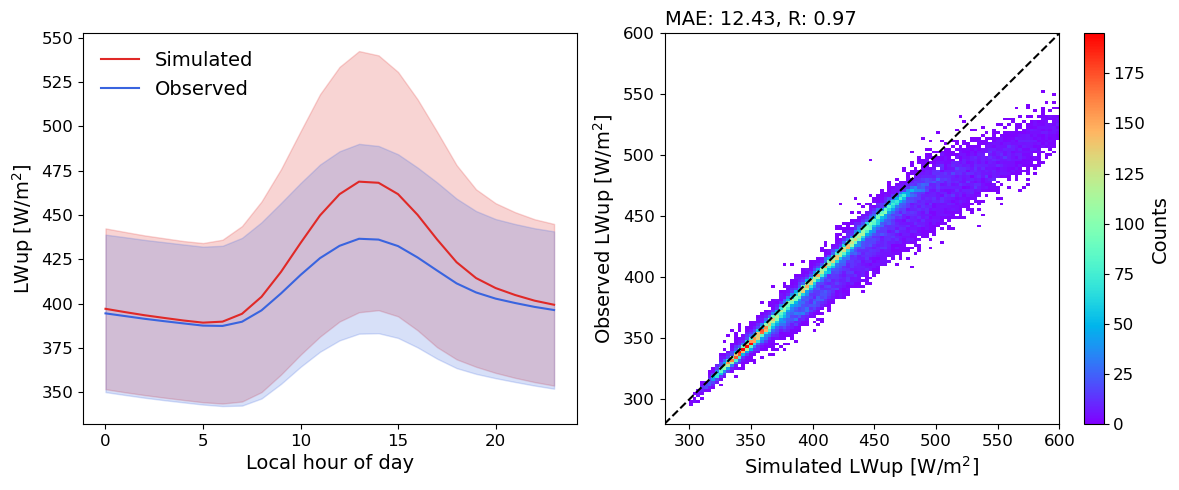

Qle MAE: 22.15


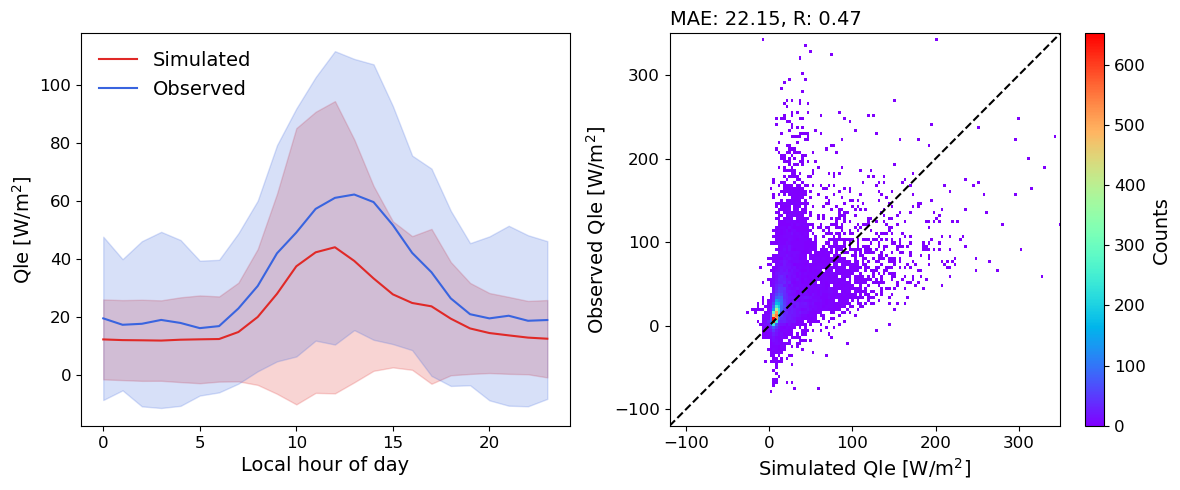

Qh MAE: 31.35


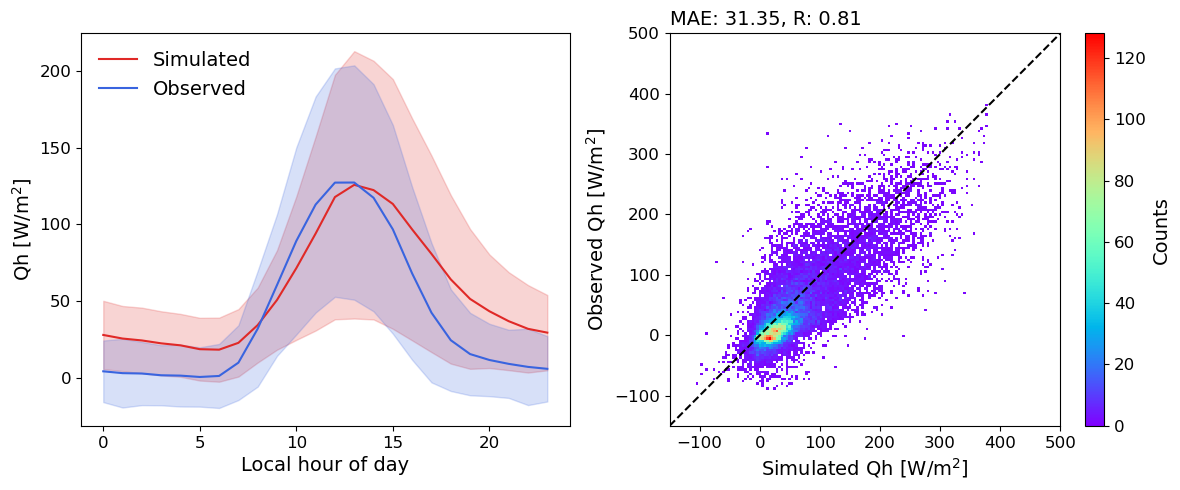

In [7]:
plotting(df, save_path='figs/JP_Yoyogi_urb')